<a href="https://colab.research.google.com/github/reobrien1/AMS_delta_functionalgroups/blob/main/Delta_plot_v1_0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Import you data. Note that the data should be three columns: mass, formula, frac_abundance. The abundance needs to be normalized to sum = 1.
data_path = '/content/drive/My Drive/Research/Chamber/photolysis_2lights/'
#df = pd.read_csv(data_path+'0729_day_S10.csv')
df = pd.read_csv(data_path+'S6.csv')
#df = pd.read_csv(data_path+'IEPOX_SOA.csv')
#df = pd.read_csv(data_path+'Al_fall.csv')
#df = pd.read_csv(data_path+'Xylitol.csv')
#df = pd.read_csv(data_path+'LOOA_winter_china.csv')
display(df.head())

,mass,formula,frac_abundance
0,12.00000,C,0.011700
1,13.00336,j13C,0.000127
2,13.00782,CH,0.003790
3,14.00307,N,0.000000
4,14.01118,j13CH,0.000041


In [ ]:
#Parse chemical formulas
import re

def parse_formula(formula):
    """
    Parses a chemical formula string to extract the counts of C, H, O, and N.

    Args:
        formula: A string representing the chemical formula.

    Returns:
        A dictionary with keys 'C', 'H', 'O', 'N' and their respective counts.
        Returns {'C': 0, 'H': 0, 'O': 0, 'N': 0} if the input is not a valid string.
    """
    counts = {'C': 0, 'H': 0, 'O': 0, 'N': 0}
    if not isinstance(formula, str):
        return counts

    # Find all element symbols and their counts using regex
    matches = re.findall(r'([A-Z][a-z]*)(\d*)', formula)

    for element, count in matches:
        if element in counts:
            counts[element] += int(count) if count else 1

    return counts

In [ ]:
#Create a table of the data with formulas and calculate the delta values
formula_counts = df['formula'].apply(parse_formula)
formula_counts_df = pd.DataFrame(list(formula_counts))
df = pd.concat([df, formula_counts_df], axis=1)

df['delta'] = df.mass - (14*(df.C + df.O + df.N)) + 1
df['delta'] = df['delta'].round()

#Remove all values that are less than 48 amu, that contain j (isotopes), do not contain the letter C and that do contain the letters S, Cl, or Cu. We are also removing N for now.
#If your data has other atoms, it would be a good idea to remove them here as well.
df = df[~(df.mass < 48)]
df = df[~df['formula'].str.contains('j', na=False)]
df = df[df['formula'].str.contains('c', case=False, na=False)]
df = df[~df['formula'].str.contains('S', case=True, na=False)]
df = df[~df['formula'].str.contains('Cl', case=True, na=False)]
df = df[~df['formula'].str.contains('Cu', case=True, na=False)]
df = df[~df['formula'].str.contains('N', case=True, na=False)]

#lump delta values <=-8 and >= +7
df.loc[df['delta'] < -8, 'delta'] = -8
df.loc[df['delta'] > 7, 'delta'] = 7
display(df.head())

,mass,formula,frac_abundance,C,H,O,N,delta
151,48.000000,C4,0.000144,4,0,0,0,-7.0
159,49.007820,C4H,0.001330,4,1,0,0,-6.0
165,50.015652,C4H2,0.007540,4,2,0,0,-5.0
170,51.023479,C4H3,0.010200,4,3,0,0,-4.0
175,52.031300,C4H4,0.005830,4,4,0,0,-3.0


In [ ]:
#Sum the frac_abundance (intensity values) for each delta. Here, we are splitting by oxygen only. Nitrogen will be included in the future.
delta_abundance = df.groupby(['O', 'delta']).agg({'frac_abundance': 'sum'})
delta_abundance = delta_abundance.reset_index()
pivot_delta_abundance = delta_abundance.pivot_table(index=['O'], columns='delta', values='frac_abundance').fillna(0)
display(pivot_delta_abundance.head(20))

delta,-8.0,-7.0,-6.0,-5.0,-4.0,-3.0,-2.0,-1.0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0
O,,,,,,,,,,,,,,,,
0,0.006880,0.002772,0.017614,0.011624,0.028028,0.011991,0.035204,0.011822,0.019287,0.002184,0.000685,0.000043,0.000000,0.000000,0.000000,0.000072
1,0.004671,0.000096,0.000414,0.001666,0.001021,0.004446,0.011259,0.015090,0.030412,0.006764,0.008785,0.006290,0.004553,0.000075,0.000000,0.000037
2,0.000107,0.000002,0.000008,0.000024,0.000283,0.001223,0.001740,0.001627,0.019644,0.003022,0.005154,0.004252,0.002653,0.002363,0.000470,0.000180
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000040,0.000000,0.000145
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000008,0.000009,0.000056
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000108


In [ ]:
#Convert the delta valeus to raidans for plotting
delta_values = pivot_delta_abundance.columns
angles = np.deg2rad(np.linspace(0, 360, len(delta_values), endpoint=False))

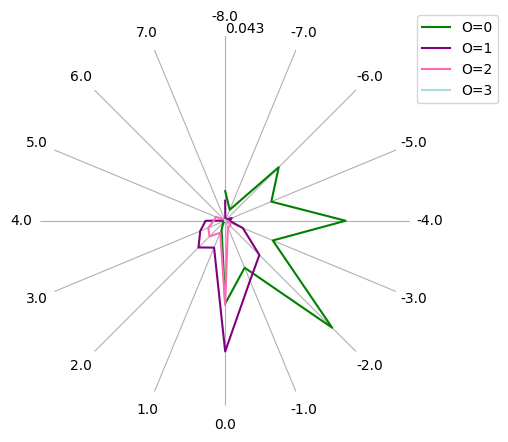

In [ ]:
#Generate the delta plot.
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

# Define specific colors for certain 'O' values
specific_colors = {
    0: 'green', 1: 'purple', 2: 'hotpink',3: 'lightblue'
}

# Define 'O' values to hide
o_to_hide = [4, 5, 6]

for index, row in pivot_delta_abundance.iterrows():
    o = index

    # Skip plotting if 'o' is in the list of values to hide
    if o in o_to_hide:
        continue
    frac_abundances = row.values

    # Assign color based on 'o' value from the specific_colors dictionary
    # If 'o' is not in specific_colors, use a default color (e.g., 'gray')
    color = specific_colors.get(o, 'gray')

    ax.plot(angles, frac_abundances, label=f'O={o}', color=color)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_rlabel_position(0)
ax.legend(loc='lower left', bbox_to_anchor=(1, 0.8))

max_abundance = delta_abundance['frac_abundance'].max()
max_abudance_rounded = round(max_abundance, 3)+0.2*round(max_abundance, 2)
ax.set_rmax(max_abudance_rounded)
ax.set_rmin(0.0)
#print(max_abudance_rounded)

ax.set_xticks(angles)
ax.set_xticklabels(delta_values)
ax.set_yticks([ax.get_rmax()])

# Remove circular radial lines by explicitly turning off the y-axis grid
ax.yaxis.grid(False)

# Make the outer ring (polar spine) transparent
ax.spines['polar'].set_color('none')

plt.show()